# Submission Akhir: Multivariate Multi-Horizon Time Series Forecasting
## Bitcoin Hourly Price Prediction menggunakan Seq2Seq LSTM

**Target:** Memprediksi harga Close Bitcoin 24 jam ke depan (multi-step forecasting)

---

## 1. Import Library dan Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

TensorFlow version: 2.20.0
NumPy version: 2.0.2
Pandas version: 2.2.2


In [2]:
# Load dataset Bitcoin
csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'
df = pd.read_csv(csv_url)
df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df = df.sort_values('Date').reset_index(drop=True)
df.set_index('Date', inplace=True)

print("Shape:", df.shape)
print("\nKolom:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
df.head()

Shape: (53150, 6)

Kolom: ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO']

Missing values:
Close          0
Volume USDT    0
RSI            0
MACD_Hist      0
ATR            0
KAMAO          0
dtype: int64


,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
Date,,,,,,
2017-09-21 09:00:00,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
2017-09-21 10:00:00,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2017-09-21 11:00:00,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
2017-09-21 12:00:00,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
2017-09-21 13:00:00,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


In [3]:
df.describe()

,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
count,53150.000000,5.315000e+04,53150.000000,53150.000000,53150.000000,53150.000000
mean,20595.357333,6.919215e+07,50.403605,0.528272,221.733334,0.229762
std,15822.296994,1.059041e+08,3.210682,353.293188,208.401440,5.168655
min,3172.050000,0.000000e+00,35.178834,-1885.690630,17.436266,-31.767152
25%,7976.915000,1.012558e+07,48.294197,-115.601600,72.702488,-2.717470
50%,13878.095000,2.766119e+07,50.038483,10.154419,128.787616,-0.032747
75%,29646.720000,8.944278e+07,52.406274,122.367509,325.616826,3.162442
max,68633.690000,3.005634e+09,64.657108,1430.405758,1004.531407,39.740297


## 2. Exploratory Data Analysis (EDA)

### 2.1 Visualisasi Harga Close Bitcoin

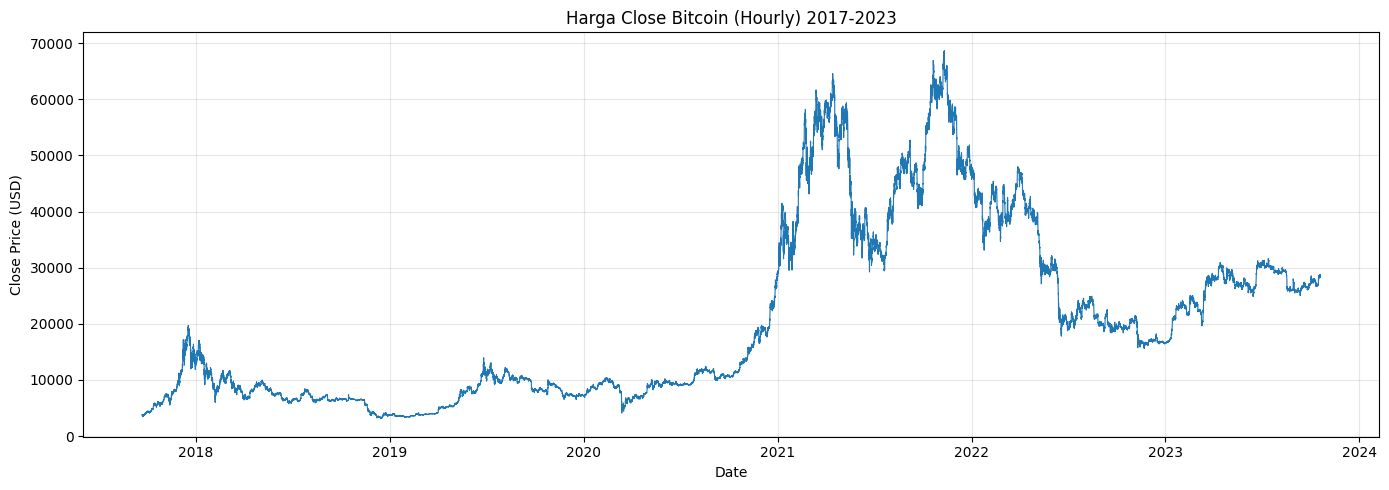

In [4]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Close'], linewidth=0.8)
plt.title('Harga Close Bitcoin (Hourly) 2017-2023')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2 Feature Engineering - Rolling Statistics

In [5]:
# Feature Engineering: membuat fitur baru menggunakan Rolling Statistic
df['Close_Rolling_Mean_24'] = df['Close'].rolling(window=24).mean()
df['Close_Rolling_Std_24'] = df['Close'].rolling(window=24).std()

# Hapus baris NaN hasil rolling
df.dropna(inplace=True)
print("Shape setelah feature engineering:", df.shape)
print("\nFitur baru:")
print("- Close_Rolling_Mean_24: Moving average 24 jam")
print("- Close_Rolling_Std_24: Rolling std 24 jam (volatilitas)")
df.head()

Shape setelah feature engineering: (53127, 8)

Fitur baru:
- Close_Rolling_Mean_24: Moving average 24 jam
- Close_Rolling_Std_24: Rolling std 24 jam (volatilitas)


,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO,Close_Rolling_Mean_24,Close_Rolling_Std_24
Date,,,,,,,,
2017-09-22 08:00:00,3647.70,98670.562044,48.507646,-49.453354,86.625836,0.015093,3709.506667,91.112560
2017-09-22 09:00:00,3606.95,107162.792190,48.366751,-49.745629,86.528735,-0.453320,3698.962917,87.510496
2017-09-22 10:00:00,3572.85,150926.427424,48.249126,-50.150669,86.412221,-0.843745,3686.520000,83.030244
2017-09-22 11:00:00,3539.97,190043.740129,48.135914,-50.661754,86.392482,-1.217532,3672.979167,79.071138
2017-09-22 12:00:00,3592.12,127074.058322,48.328786,-50.963345,86.373427,-0.610674,3661.897500,70.133487


### 2.3 Pemilihan Fitur dan Heatmap Korelasi

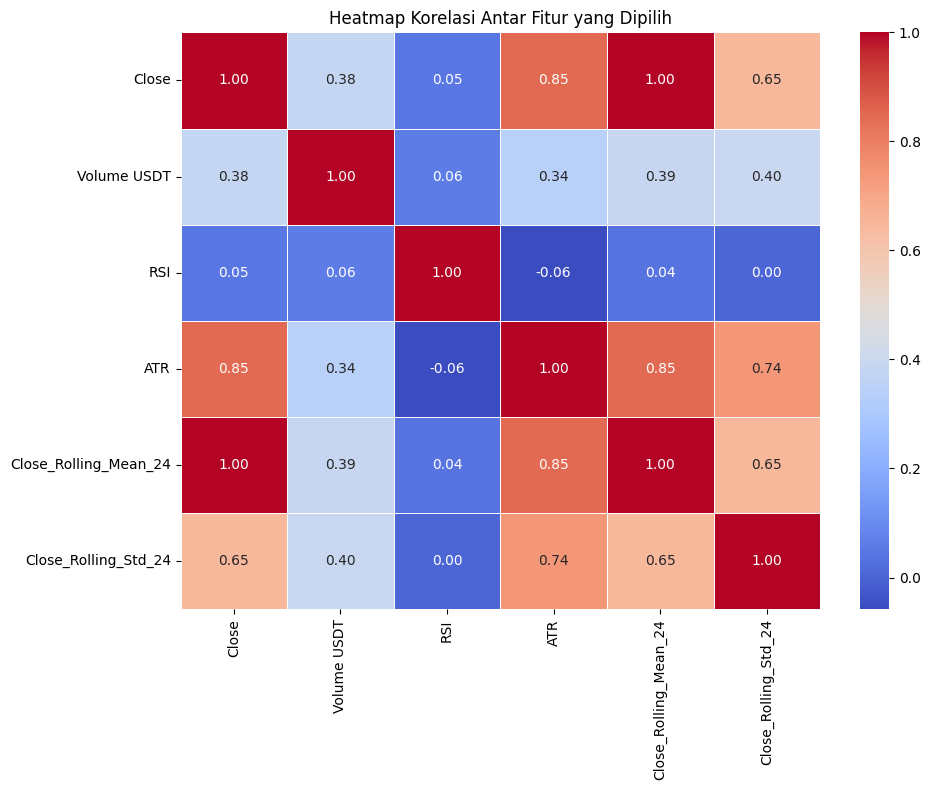

In [6]:
# Pilih minimal 3 fitur + target
selected_features = ['Close', 'Volume USDT', 'RSI', 'ATR', 'Close_Rolling_Mean_24', 'Close_Rolling_Std_24']

plt.figure(figsize=(10, 8))
corr_matrix = df[selected_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur yang Dipilih')
plt.tight_layout()
plt.show()

### 2.4 Dekomposisi Time Series pada Data Target (Close)

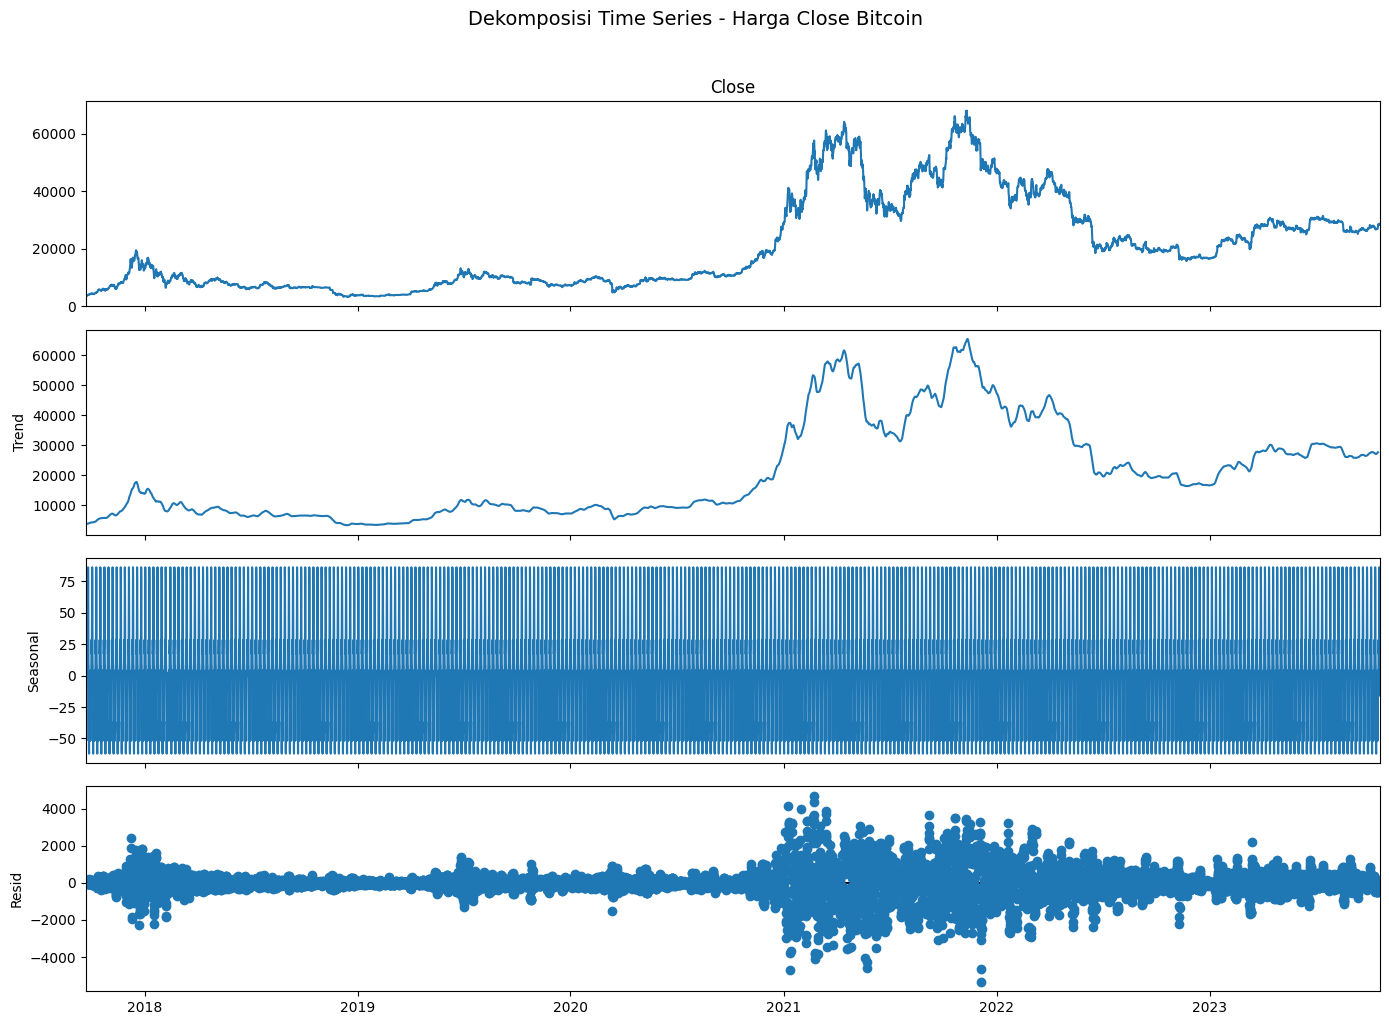

In [7]:
# Resample ke 6-jam untuk efisiensi
close_resampled = df['Close'].resample('6h').mean().dropna()

decomposition = seasonal_decompose(close_resampled, model='additive', period=28)
fig = decomposition.plot()
fig.set_size_inches(14, 10)
fig.suptitle('Dekomposisi Time Series - Harga Close Bitcoin', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2.5 Analisis ACF dan PACF untuk Menentukan Window Size

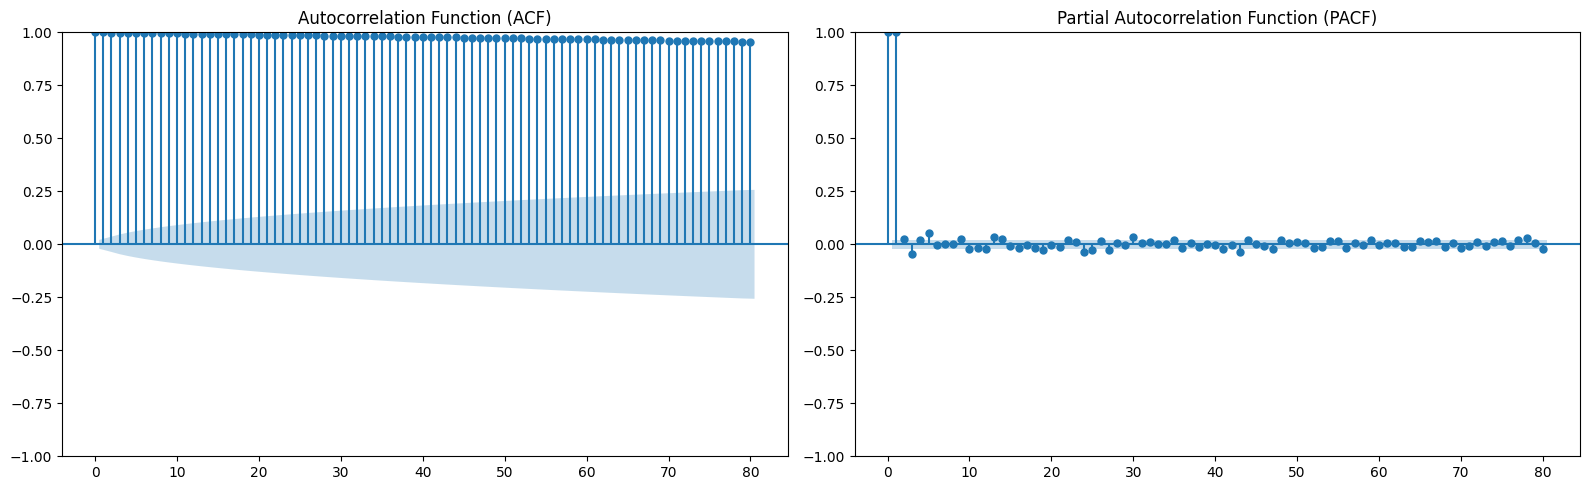

Hasil Analisis ACF & PACF:
- ACF: slowly decaying -> non-stasioner, autokorelasi signifikan hingga banyak lag
- PACF: significant drop setelah beberapa lag awal
- Window Size dipilih: 48 (2 hari) untuk memprediksi 24 jam ke depan


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subsample agar plot lebih jelas
plot_acf(df['Close'].values[::6], lags=80, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

plot_pacf(df['Close'].values[::6], lags=80, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

print("Hasil Analisis ACF & PACF:")
print("- ACF: slowly decaying -> non-stasioner, autokorelasi signifikan hingga banyak lag")
print("- PACF: significant drop setelah beberapa lag awal")
print("- Window Size dipilih: 48 (2 hari) untuk memprediksi 24 jam ke depan")

## 3. Preprocessing Data

### 3.1 Split Data SEBELUM Normalisasi (No Data Leakage)

In [9]:
# Parameter utama
WINDOW_SIZE = 48   # 48 jam input
HORIZON = 24       # 24 jam prediksi ke depan
TARGET_COL = 'Close'

feature_columns = ['Close', 'Volume USDT', 'RSI', 'ATR', 'Close_Rolling_Mean_24', 'Close_Rolling_Std_24']
data = df[feature_columns].values

# Split: 70% train, 15% val, 15% test
n = len(data)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = data[:train_end]
val_data   = data[train_end:val_end]
test_data  = data[val_end:]

print(f"Total data  : {n}")
print(f"Train data  : {train_data.shape[0]} ({train_data.shape[0]/n*100:.1f}%)")
print(f"Val data    : {val_data.shape[0]} ({val_data.shape[0]/n*100:.1f}%)")
print(f"Test data   : {test_data.shape[0]} ({test_data.shape[0]/n*100:.1f}%)")

Total data  : 53127
Train data  : 37188 (70.0%)
Val data    : 7969 (15.0%)
Test data   : 7970 (15.0%)


### 3.2 Normalisasi (Fit HANYA pada Train Data)

In [10]:
# Normalisasi per fitur - FIT HANYA PADA TRAIN untuk menghindari data leakage
scalers = {}
train_scaled = np.zeros_like(train_data, dtype=np.float32)
val_scaled   = np.zeros_like(val_data, dtype=np.float32)
test_scaled  = np.zeros_like(test_data, dtype=np.float32)

for i, col in enumerate(feature_columns):
    scaler = MinMaxScaler()
    train_scaled[:, i] = scaler.fit_transform(train_data[:, i].reshape(-1, 1)).flatten()
    val_scaled[:, i]   = scaler.transform(val_data[:, i].reshape(-1, 1)).flatten()
    test_scaled[:, i]  = scaler.transform(test_data[:, i].reshape(-1, 1)).flatten()
    scalers[col] = scaler

print("Normalisasi selesai - Scaler di-fit HANYA pada data train!")
print(f"Train range: [{train_scaled.min():.4f}, {train_scaled.max():.4f}]")
print(f"Val range  : [{val_scaled.min():.4f}, {val_scaled.max():.4f}]")
print(f"Test range : [{test_scaled.min():.4f}, {test_scaled.max():.4f}]")

Normalisasi selesai - Scaler di-fit HANYA pada data train!
Train range: [0.0000, 1.0000]
Val range  : [0.0035, 1.9846]
Test range : [0.0000, 1.3332]


### 3.3 Membuat Windowed Dataset

In [11]:
def create_windows(data, window_size, horizon, target_idx=0):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size : i + window_size + horizon, target_idx])
    return np.array(X), np.array(y)

target_idx = feature_columns.index(TARGET_COL)

X_train, y_train = create_windows(train_scaled, WINDOW_SIZE, HORIZON, target_idx)
X_val, y_val     = create_windows(val_scaled, WINDOW_SIZE, HORIZON, target_idx)
X_test, y_test   = create_windows(test_scaled, WINDOW_SIZE, HORIZON, target_idx)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}, y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}, y_test : {y_test.shape}")

X_train: (37117, 48, 6), y_train: (37117, 24)
X_val  : (7898, 48, 6), y_val  : (7898, 24)
X_test : (7899, 48, 6), y_test : (7899, 24)


### 3.4 tf.data.Dataset Pipeline

In [12]:
BATCH_SIZE = 64

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset   = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset  = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

for bx, by in train_dataset.take(1):
    print(f"Batch X: {bx.shape}, Batch y: {by.shape}")
print("\ntf.data.Dataset pipeline berhasil dibuat!")

Batch X: (64, 48, 6), Batch y: (64, 24)

tf.data.Dataset pipeline berhasil dibuat!


## 4. Custom Layers

### 4.1 Custom Dense Layer (dibuat dari nol)

In [13]:
class CustomDense(keras.layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = keras.activations.get(activation)

    def build(self, input_shape):
        self.w = self.add_weight(shape=(input_shape[-1], self.units),
                                 initializer='glorot_uniform', trainable=True, name='kernel')
        self.b = self.add_weight(shape=(self.units,),
                                 initializer='zeros', trainable=True, name='bias')

    def call(self, inputs):
        output = tf.matmul(inputs, self.w) + self.b
        if self.activation is not None:
            output = self.activation(output)
        return output

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units,
                       'activation': keras.activations.serialize(self.activation)})
        return config

print("CustomDense layer berhasil dibuat!")

CustomDense layer berhasil dibuat!


### 4.2 Custom Multi-Head Attention Layer (dibuat dari nol)

In [14]:
class CustomMultiHeadAttention(keras.layers.Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super().__init__(**kwargs)
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.depth = d_model // num_heads

    def build(self, input_shape):
        dim = input_shape[-1]
        self.wq = self.add_weight(shape=(dim, self.d_model), initializer='glorot_uniform', trainable=True, name='wq')
        self.wk = self.add_weight(shape=(dim, self.d_model), initializer='glorot_uniform', trainable=True, name='wk')
        self.wv = self.add_weight(shape=(dim, self.d_model), initializer='glorot_uniform', trainable=True, name='wv')
        self.wo = self.add_weight(shape=(self.d_model, self.d_model), initializer='glorot_uniform', trainable=True, name='wo')

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        q = self.split_heads(tf.matmul(inputs, self.wq), batch_size)
        k = self.split_heads(tf.matmul(inputs, self.wk), batch_size)
        v = self.split_heads(tf.matmul(inputs, self.wv), batch_size)

        dk = tf.cast(self.depth, tf.float32)
        scores = tf.matmul(q, k, transpose_b=True) / tf.math.sqrt(dk)
        weights = tf.nn.softmax(scores, axis=-1)
        attention = tf.matmul(weights, v)

        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        concat = tf.reshape(attention, (batch_size, -1, self.d_model))
        output = tf.matmul(concat, self.wo)
        return output

    def get_config(self):
        config = super().get_config()
        config.update({'d_model': self.d_model, 'num_heads': self.num_heads})
        return config

print("CustomMultiHeadAttention layer berhasil dibuat!")

CustomMultiHeadAttention layer berhasil dibuat!


### 4.3 Custom Dropout Layer (dibuat dari nol)

In [15]:
class CustomDropout(keras.layers.Layer):
    def __init__(self, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate

    def call(self, inputs, training=None):
        if training:
            mask = tf.random.uniform(tf.shape(inputs)) > self.rate
            return inputs * tf.cast(mask, inputs.dtype) / (1.0 - self.rate)
        return inputs

    def get_config(self):
        config = super().get_config()
        config.update({'rate': self.rate})
        return config

print("CustomDropout layer berhasil dibuat!")

CustomDropout layer berhasil dibuat!


### 4.4 Custom Layer Normalization (dibuat dari nol)

In [16]:
class CustomLayerNorm(keras.layers.Layer):
    def __init__(self, epsilon=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        self.gamma = self.add_weight(shape=(input_shape[-1],), initializer='ones', trainable=True, name='gamma')
        self.beta  = self.add_weight(shape=(input_shape[-1],), initializer='zeros', trainable=True, name='beta')

    def call(self, inputs):
        mean = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        var  = tf.math.reduce_variance(inputs, axis=-1, keepdims=True)
        return self.gamma * (inputs - mean) / tf.sqrt(var + self.epsilon) + self.beta

    def get_config(self):
        config = super().get_config()
        config.update({'epsilon': self.epsilon})
        return config

print("CustomLayerNorm layer berhasil dibuat!")

CustomLayerNorm layer berhasil dibuat!


## 5. Model Baseline LSTM + Multi-Head Attention

In [17]:
N_FEATURES = len(feature_columns)

inputs = keras.Input(shape=(WINDOW_SIZE, N_FEATURES), name='input')
x = keras.layers.LSTM(128, return_sequences=True, name='lstm_1')(inputs)
x = CustomDropout(0.2, name='drop_1')(x)
x = CustomMultiHeadAttention(d_model=128, num_heads=4, name='custom_mha')(x)
x = CustomLayerNorm(name='custom_ln')(x)
x = keras.layers.LSTM(64, return_sequences=False, name='lstm_2')(x)
x = CustomDropout(0.2, name='drop_2')(x)
x = CustomDense(64, activation='relu', name='custom_dense_1')(x)
outputs = CustomDense(HORIZON, name='custom_dense_out')(x)

model_baseline = keras.Model(inputs=inputs, outputs=outputs, name='Baseline_LSTM_MHA')
model_baseline.summary()

Model: "Baseline_LSTM_MHA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 48, 128)        │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (CustomDropout)          │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_mha                      │ (None, None, 128)      │        65,536 │
│ (CustomMultiHeadAttention)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_ln (CustomLayerNorm)     │ (None, None, 128)      │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (CustomDropout)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense_1 (CustomDense)    │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense_out (CustomDense)  │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 190,040 (742.34 KB)

 Trainable params: 190,040 (742.34 KB)

 Non-trainable params: 0 (0.00 B)

### 5.1 Training Baseline dengan model.fit()

In [18]:
model_baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mae'
)

history_baseline = model_baseline.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
    ],
    verbose=1
)

Epoch 1/30
580/580 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.0267 - val_loss: 0.0576 - learning_rate: 0.0010
Epoch 2/30
580/580 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0207 - val_loss: 0.0248 - learning_rate: 0.0010
Epoch 3/30
580/580 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0147 - val_loss: 0.0208 - learning_rate: 0.0010
Epoch 4/30
580/580 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0144 - val_loss: 0.0181 - learning_rate: 0.0010
Epoch 5/30
580/580 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0128 - val_loss: 0.0181 - learning_rate: 0.0010
Epoch 6/30
580/580 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0122 - val_loss: 0.0219 - learning_rate: 0.0010
Epoch 7/30
580/580 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0076
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
580/580 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0112 - val_loss: 0.0196 - learning_rate: 0.0010
Epoch 8/30
580/580 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.0099 - val_loss: 0.0197 - 

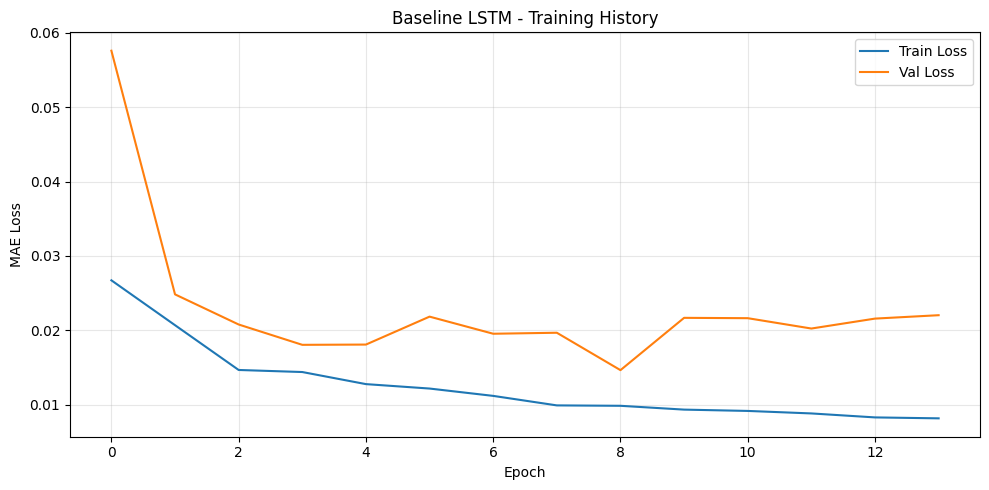

In [19]:
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Val Loss')
plt.title('Baseline LSTM - Training History')
plt.xlabel('Epoch'); plt.ylabel('MAE Loss'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [20]:
# Evaluasi dan simpan
baseline_test_loss = model_baseline.evaluate(test_dataset, verbose=0)
print(f"Baseline LSTM - Test MAE (scaled): {baseline_test_loss:.6f}")

model_baseline.save('model_baseline_LSTM.keras')
print("Model baseline berhasil disimpan!")

Baseline LSTM - Test MAE (scaled): 0.010899
Model baseline berhasil disimpan!


## 6. Seq2Seq LSTM dengan Teacher Forcing (Model Subclassing)

In [21]:
class Seq2SeqLSTM(keras.Model):
    def __init__(self, lstm_units=128, horizon=24, n_features=6, **kwargs):
        super().__init__(**kwargs)
        self.lstm_units = lstm_units
        self.horizon = horizon
        self.n_features = n_features

        # Encoder
        self.enc_lstm = keras.layers.LSTM(lstm_units, return_sequences=True, return_state=True)
        self.enc_attn = CustomMultiHeadAttention(d_model=lstm_units, num_heads=4)
        self.enc_norm = CustomLayerNorm()
        self.enc_drop = CustomDropout(0.2)

        # Decoder
        self.dec_cell = keras.layers.LSTMCell(lstm_units)
        self.dec_attn = CustomMultiHeadAttention(d_model=lstm_units, num_heads=4)
        self.dec_norm = CustomLayerNorm()
        # Dense untuk menggabungkan decoder state + encoder context
        self.dec_context_dense = CustomDense(lstm_units, activation='relu')
        self.dec_dense = CustomDense(1)

    def call(self, inputs, training=None, teacher_forcing_targets=None):
        # Encode
        enc_out, state_h, state_c = self.enc_lstm(inputs)
        attn_out = self.enc_attn(enc_out)
        attn_out = self.enc_norm(attn_out + enc_out)  # Residual
        enc_out = self.enc_drop(attn_out, training=training)

        # Context vector dari encoder (mean pooling)
        enc_context = tf.reduce_mean(enc_out, axis=1)  # (batch, units)
        state = [state_h, state_c]

        if training and teacher_forcing_targets is not None:
            return self._teacher_forcing_decode(inputs, enc_context, state, teacher_forcing_targets)
        else:
            return self._autoregressive_decode(inputs, enc_context, state)

    def _teacher_forcing_decode(self, inputs, enc_context, state, targets):
        outputs = []
        current_input = inputs[:, -1, 0:1]  # Start token: last Close

        for t in range(self.horizon):
            x_t, state = self.dec_cell(current_input, state)
            x_t_exp = tf.expand_dims(x_t, axis=1)
            a = self.dec_attn(x_t_exp)
            a = self.dec_norm(a + x_t_exp)
            a = tf.squeeze(a, axis=1)
            # Gabungkan dengan encoder context
            combined = self.dec_context_dense(a + enc_context)
            out = self.dec_dense(combined)
            outputs.append(out)
            current_input = targets[:, t:t+1]  # Teacher forcing

        return tf.squeeze(tf.stack(outputs, axis=1), axis=-1)

    def _autoregressive_decode(self, inputs, enc_context, state):
        outputs = []
        current_input = inputs[:, -1, 0:1]

        for t in range(self.horizon):
            x_t, state = self.dec_cell(current_input, state)
            x_t_exp = tf.expand_dims(x_t, axis=1)
            a = self.dec_attn(x_t_exp)
            a = self.dec_norm(a + x_t_exp)
            a = tf.squeeze(a, axis=1)
            combined = self.dec_context_dense(a + enc_context)
            out = self.dec_dense(combined)
            outputs.append(out)
            current_input = out  # Autoregressive

        return tf.squeeze(tf.stack(outputs, axis=1), axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({'lstm_units': self.lstm_units, 'horizon': self.horizon, 'n_features': self.n_features})
        return config

# Build model
seq2seq_model = Seq2SeqLSTM(lstm_units=128, horizon=HORIZON, n_features=N_FEATURES)
dummy = tf.random.normal((2, WINDOW_SIZE, N_FEATURES))
_ = seq2seq_model(dummy, training=False)
seq2seq_model.summary()
print("\nSeq2Seq LSTM berhasil dibangun!")

Model: "seq2_seq_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ ((2, 48, 128), (2,     │        69,120 │
│                                 │ 128), (2, 128))        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_multi_head_attention     │ ?                      │        65,536 │
│ (CustomMultiHeadAttention)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_layer_norm               │ ?                      │           256 │
│ (CustomLayerNorm)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dropout (CustomDropout)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_cell (LSTMCell)            │ ?                      │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_multi_head_attention_1   │ ?                      │        65,536 │
│ (CustomMultiHeadAttention)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_layer_norm_1             │ ?                      │           256 │
│ (CustomLayerNorm)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense (CustomDense)      │ ?                      │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense_1 (CustomDense)    │ ?                      │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283,905 (1.08 MB)

 Trainable params: 283,905 (1.08 MB)

 Non-trainable params: 0 (0.00 B)


Seq2Seq LSTM berhasil dibangun!


## 7. Custom Loss dan Custom Callbacks

### 7.1 Custom Weighted MAE Loss (Horizon-Weighted)

In [22]:
class WeightedMAELoss:
    """
    Custom Weighted MAE: step yang lebih jauh mendapat bobot lebih besar.
    Contoh: step 1 -> w=1.0, step 2 -> w=1.02, step 3 -> w=1.04, dst.
    """
    def __init__(self, horizon, base_weight=1.0, increment=0.02):
        self.weights = tf.constant(
            [base_weight + i * increment for i in range(horizon)], dtype=tf.float32
        )
        self.weights = self.weights / tf.reduce_mean(self.weights)

    def __call__(self, y_true, y_pred):
        errors = tf.abs(y_true - y_pred)
        weighted = errors * self.weights
        return tf.reduce_mean(weighted)

# Custom MAE dari nol
def custom_mae_loss(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

weighted_loss_fn = WeightedMAELoss(horizon=HORIZON, base_weight=1.0, increment=0.02)
print("Horizon weights:", weighted_loss_fn.weights.numpy().round(4))
print("Custom Loss functions berhasil dibuat!")

Horizon weights: [0.813  0.8293 0.8455 0.8618 0.878  0.8943 0.9106 0.9268 0.9431 0.9593
 0.9756 0.9919 1.0081 1.0244 1.0407 1.0569 1.0732 1.0894 1.1057 1.122
 1.1382 1.1545 1.1707 1.187 ]
Custom Loss functions berhasil dibuat!


### 7.2 Custom Early Stopping Callback

In [23]:
class CustomEarlyStopping:
    def __init__(self, patience=5, min_delta=0.0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = float('inf')
        self.wait = 0
        self.best_weights = None
        self.stopped = False

    def on_epoch_end(self, model, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.wait = 0
            if self.restore_best_weights:
                self.best_weights = model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped = True
                if self.restore_best_weights and self.best_weights is not None:
                    model.set_weights(self.best_weights)
                    print(f"  Early stopping! Restoring best weights (val_loss: {self.best_loss:.6f})")
                else:
                    print(f"  Early stopping!")
        return self.stopped

print("CustomEarlyStopping berhasil dibuat!")

CustomEarlyStopping berhasil dibuat!


### 7.3 Custom ReduceLROnPlateau Callback

In [24]:
class CustomReduceLR:
    def __init__(self, optimizer, patience=3, factor=0.5, min_lr=1e-7, verbose=True):
        self.optimizer = optimizer
        self.patience = patience
        self.factor = factor
        self.min_lr = min_lr
        self.verbose = verbose
        self.best_loss = float('inf')
        self.wait = 0

    def on_epoch_end(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                old_lr = float(self.optimizer.learning_rate.numpy())
                new_lr = max(old_lr * self.factor, self.min_lr)
                self.optimizer.learning_rate.assign(new_lr)
                self.wait = 0
                if self.verbose:
                    print(f"  ReduceLR: lr {old_lr:.2e} -> {new_lr:.2e}")

print("CustomReduceLR berhasil dibuat!")

CustomReduceLR berhasil dibuat!


## 8. Custom Training Loop dengan tf.GradientTape

In [25]:
EPOCHS = 50
LEARNING_RATE = 0.001

optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
weighted_loss_fn = WeightedMAELoss(horizon=HORIZON, base_weight=1.0, increment=0.02)

early_stopping = CustomEarlyStopping(patience=7, restore_best_weights=True)
reduce_lr = CustomReduceLR(optimizer, patience=3, factor=0.5)

@tf.function
def train_step(model, x_batch, y_batch, optimizer, loss_fn):
    with tf.GradientTape() as tape:
        predictions = model(x_batch, training=True, teacher_forcing_targets=y_batch)
        loss = loss_fn(y_batch, predictions)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

@tf.function
def val_step(model, x_batch, y_batch, loss_fn):
    predictions = model(x_batch, training=False)
    return loss_fn(y_batch, predictions)

print("Training functions siap!")

Training functions siap!


In [26]:
# ============ CUSTOM TRAINING LOOP ============
print("=" * 60)
print("CUSTOM TRAINING - Seq2Seq LSTM")
print("=" * 60)

history_seq2seq = {'loss': [], 'val_loss': []}

for epoch in range(EPOCHS):
    train_losses = []
    for x_batch, y_batch in train_dataset:
        loss = train_step(seq2seq_model, x_batch, y_batch, optimizer, weighted_loss_fn)
        train_losses.append(loss.numpy())
    avg_train = np.mean(train_losses)

    val_losses = []
    for x_batch, y_batch in val_dataset:
        loss = val_step(seq2seq_model, x_batch, y_batch, weighted_loss_fn)
        val_losses.append(loss.numpy())
    avg_val = np.mean(val_losses)

    history_seq2seq['loss'].append(avg_train)
    history_seq2seq['val_loss'].append(avg_val)

    lr = float(optimizer.learning_rate.numpy())
    print(f"Epoch {epoch+1:3d}/{EPOCHS} - loss: {avg_train:.6f} - val_loss: {avg_val:.6f} - lr: {lr:.2e}")

    reduce_lr.on_epoch_end(avg_val)
    if early_stopping.on_epoch_end(seq2seq_model, avg_val):
        print(f"\nTraining dihentikan pada epoch {epoch+1}")
        break

print("\nTraining selesai!")

CUSTOM TRAINING - Seq2Seq LSTM
Epoch   1/50 - loss: 0.089590 - val_loss: 0.071694 - lr: 1.00e-03
Epoch   2/50 - loss: 0.026635 - val_loss: 0.140478 - lr: 1.00e-03
Epoch   3/50 - loss: 0.018946 - val_loss: 0.036139 - lr: 1.00e-03
Epoch   4/50 - loss: 0.017055 - val_loss: 0.036726 - lr: 1.00e-03
Epoch   5/50 - loss: 0.011493 - val_loss: 0.028704 - lr: 1.00e-03
Epoch   6/50 - loss: 0.012988 - val_loss: 0.037879 - lr: 1.00e-03
Epoch   7/50 - loss: 0.009950 - val_loss: 0.017096 - lr: 1.00e-03
Epoch   8/50 - loss: 0.013137 - val_loss: 0.022828 - lr: 1.00e-03
Epoch   9/50 - loss: 0.009341 - val_loss: 0.025944 - lr: 1.00e-03
Epoch  10/50 - loss: 0.007957 - val_loss: 0.124024 - lr: 1.00e-03
  ReduceLR: lr 1.00e-03 -> 5.00e-04
Epoch  11/50 - loss: 0.004220 - val_loss: 0.016304 - lr: 5.00e-04
Epoch  12/50 - loss: 0.004654 - val_loss: 0.104412 - lr: 5.00e-04
Epoch  13/50 - loss: 0.006325 - val_loss: 0.035410 - lr: 5.00e-04
Epoch  14/50 - loss: 0.004860 - val_loss: 0.164285 - lr: 5.00e-04
  ReduceL

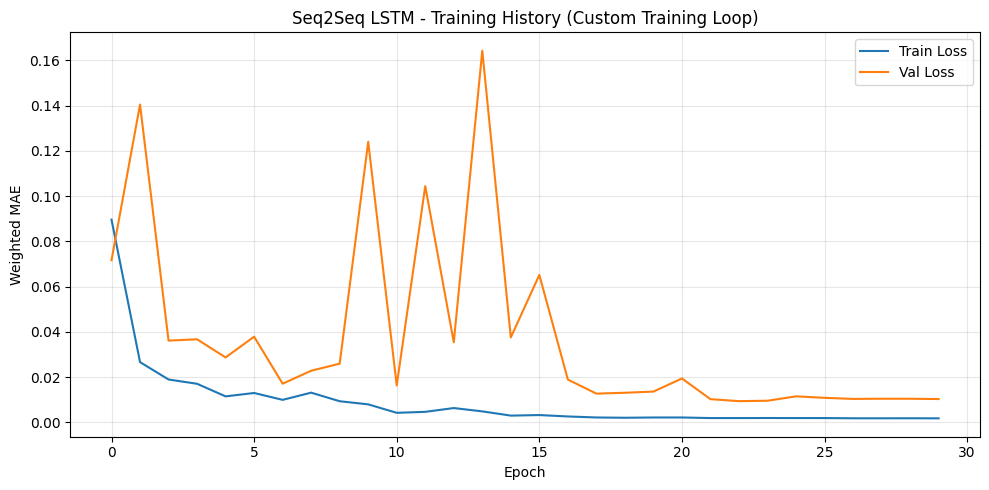

In [27]:
# Plot history
plt.figure(figsize=(10, 5))
plt.plot(history_seq2seq['loss'], label='Train Loss')
plt.plot(history_seq2seq['val_loss'], label='Val Loss')
plt.title('Seq2Seq LSTM - Training History (Custom Training Loop)')
plt.xlabel('Epoch'); plt.ylabel('Weighted MAE'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Evaluasi dan Inference

In [28]:
# Evaluasi pada test set
test_losses = []
for x_batch, y_batch in test_dataset:
    preds = seq2seq_model(x_batch, training=False)
    loss = custom_mae_loss(y_batch, preds)
    test_losses.append(loss.numpy())

seq2seq_test_mae = np.mean(test_losses)
print(f"Seq2Seq LSTM - Test MAE (scaled): {seq2seq_test_mae:.6f}")
print(f"Target MAE < 0.015: {'TERCAPAI' if seq2seq_test_mae < 0.015 else 'BELUM TERCAPAI'}")

Seq2Seq LSTM - Test MAE (scaled): 0.008022
Target MAE < 0.015: TERCAPAI


In [29]:
# Simpan model
seq2seq_model.save('model_seq2seq_LSTM.keras')
seq2seq_model.save('best_model_seq2seq_LSTM.keras')
print("Model Seq2Seq berhasil disimpan!")

Model Seq2Seq berhasil disimpan!


### 9.1 Inference Baseline LSTM

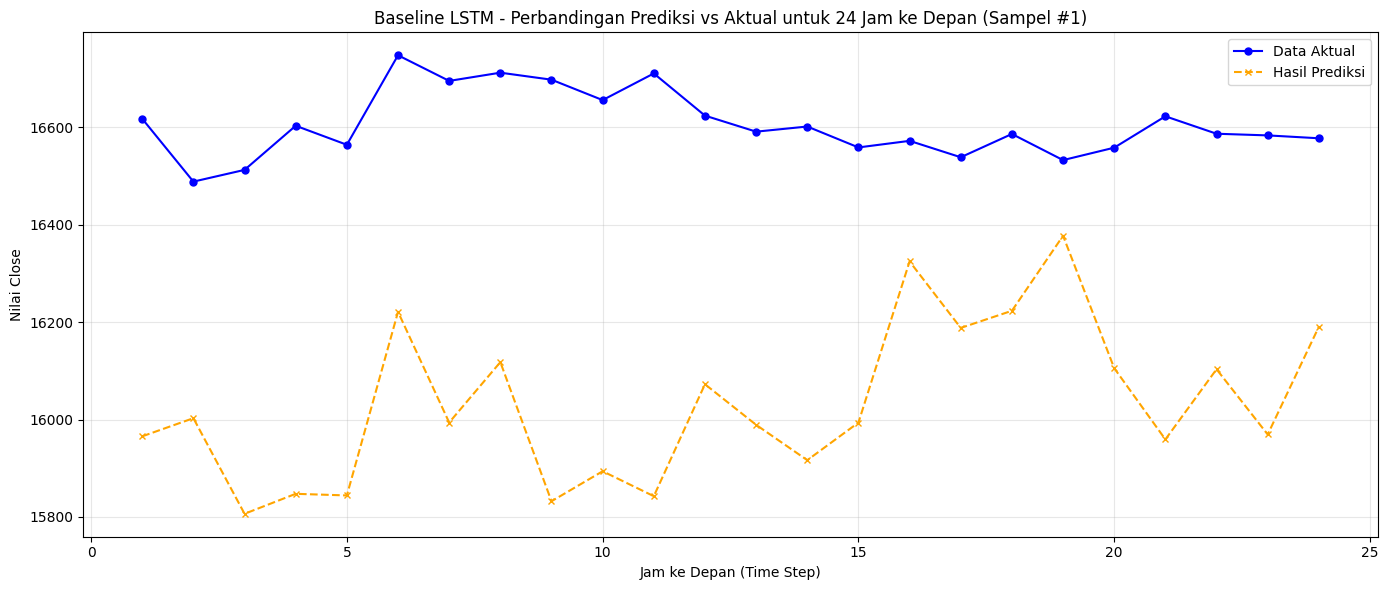

,Jam ke,Data Aktual,Hasil Prediksi,Selisih
0,1,16617.468750,15965.550781,651.917969
1,2,16488.408203,16002.760742,485.647461
2,3,16512.509766,15806.500977,706.008789
3,4,16603.109375,15847.522461,755.586914
4,5,16564.068359,15844.179688,719.888672
5,6,16747.830078,16221.049805,526.780273
6,7,16695.179688,15993.892578,701.287109
7,8,16712.068359,16117.828125,594.240234
8,9,16697.689453,15832.252930,865.436523
9,10,16655.798828,15893.815430,761.983398


In [30]:
sample_idx = 0
sample_x = X_test[sample_idx:sample_idx+1]
sample_y_true = y_test[sample_idx]

baseline_pred = model_baseline.predict(sample_x, verbose=0)[0]

close_scaler = scalers['Close']
y_true_inv = close_scaler.inverse_transform(sample_y_true.reshape(-1, 1)).flatten()
baseline_inv = close_scaler.inverse_transform(baseline_pred.reshape(-1, 1)).flatten()

plt.figure(figsize=(14, 6))
steps = range(1, HORIZON + 1)
plt.plot(steps, y_true_inv, 'b-o', label='Data Aktual', markersize=5)
plt.plot(steps, baseline_inv, color='orange', linestyle='--', marker='x', label='Hasil Prediksi', markersize=5)
plt.title(f'Baseline LSTM - Perbandingan Prediksi vs Aktual untuk 24 Jam ke Depan (Sampel #{sample_idx+1})')
plt.xlabel('Jam ke Depan (Time Step)'); plt.ylabel('Nilai Close')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

df_cmp = pd.DataFrame({
    'Jam ke': range(1, HORIZON+1),
    'Data Aktual': y_true_inv,
    'Hasil Prediksi': baseline_inv,
    'Selisih': np.abs(y_true_inv - baseline_inv)
})
df_cmp

### 9.2 Inference Seq2Seq LSTM (Autoregressive)

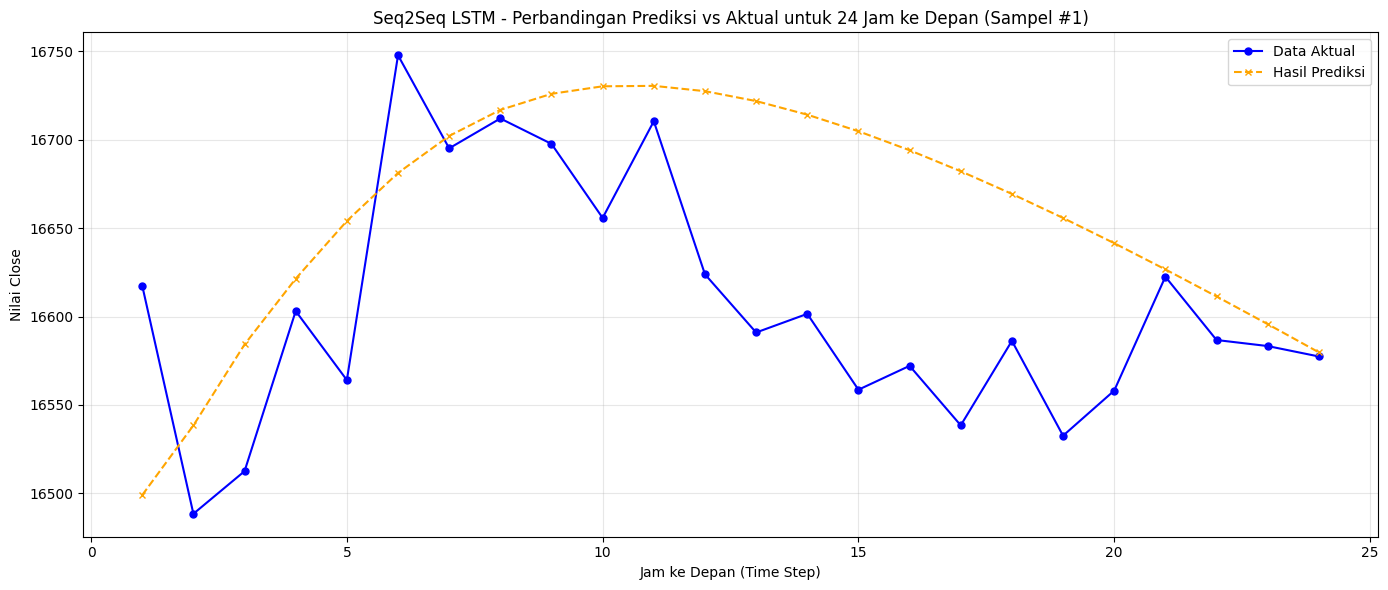

,Jam ke,Data Aktual,Hasil Prediksi,Selisih
0,1,16617.468750,16499.005859,118.462891
1,2,16488.408203,16538.400391,49.992188
2,3,16512.509766,16584.197266,71.687500
3,4,16603.109375,16621.421875,18.312500
4,5,16564.068359,16654.076172,90.007812
5,6,16747.830078,16681.238281,66.591797
6,7,16695.179688,16702.171875,6.992188
7,8,16712.068359,16716.910156,4.841797
8,9,16697.689453,16726.011719,28.322266
9,10,16655.798828,16730.269531,74.470703


In [31]:
seq2seq_pred = seq2seq_model(tf.constant(sample_x, dtype=tf.float32), training=False).numpy()[0]
seq2seq_inv = close_scaler.inverse_transform(seq2seq_pred.reshape(-1, 1)).flatten()

plt.figure(figsize=(14, 6))
plt.plot(steps, y_true_inv, 'b-o', label='Data Aktual', markersize=5)
plt.plot(steps, seq2seq_inv, color='orange', linestyle='--', marker='x', label='Hasil Prediksi', markersize=5)
plt.title(f'Seq2Seq LSTM - Perbandingan Prediksi vs Aktual untuk 24 Jam ke Depan (Sampel #{sample_idx+1})')
plt.xlabel('Jam ke Depan (Time Step)'); plt.ylabel('Nilai Close')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

df_cmp2 = pd.DataFrame({
    'Jam ke': range(1, HORIZON+1),
    'Data Aktual': y_true_inv,
    'Hasil Prediksi': seq2seq_inv,
    'Selisih': np.abs(y_true_inv - seq2seq_inv)
})
df_cmp2

### 9.3 Perbandingan Kedua Model

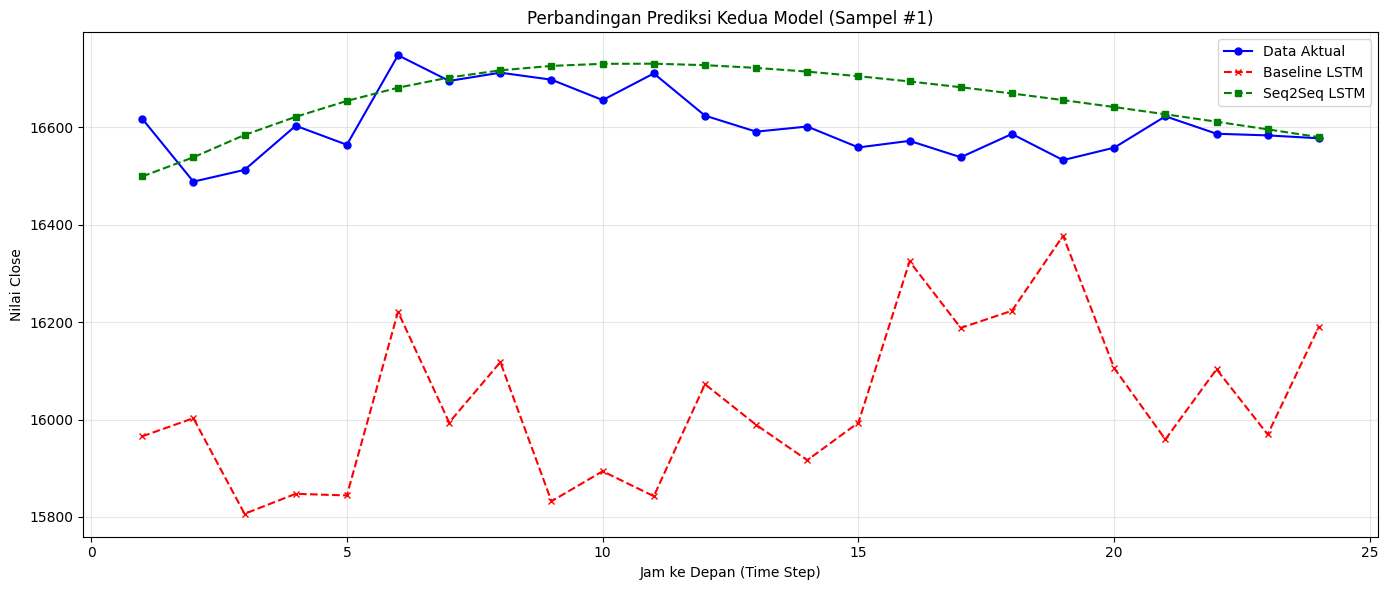


Ringkasan Performa Test Set (scaled):
  Baseline LSTM   - MAE: 0.010899
  Seq2Seq LSTM    - MAE: 0.008022


In [32]:
plt.figure(figsize=(14, 6))
plt.plot(steps, y_true_inv, 'b-o', label='Data Aktual', markersize=5)
plt.plot(steps, baseline_inv, 'r--x', label='Baseline LSTM', markersize=5)
plt.plot(steps, seq2seq_inv, 'g--s', label='Seq2Seq LSTM', markersize=5)
plt.title(f'Perbandingan Prediksi Kedua Model (Sampel #{sample_idx+1})')
plt.xlabel('Jam ke Depan (Time Step)'); plt.ylabel('Nilai Close')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"\nRingkasan Performa Test Set (scaled):")
print(f"  Baseline LSTM   - MAE: {baseline_test_loss:.6f}")
print(f"  Seq2Seq LSTM    - MAE: {seq2seq_test_mae:.6f}")

## 10. Baseline XGBoost (Lag & Rolling Features)

Sebagai pembanding terhadap arsitektur sekuensial, ditambahkan baseline XGBoost yang dilatih pada fitur lag, rolling statistics, dan encoding waktu siklikal. Prediksi multi-horizon 24 langkah ditangani dengan `MultiOutputRegressor`. Target dinormalisasi memakai scaler yang sama dengan model LSTM agar metrik MAE berada pada skala yang setara, sehingga perbandingan bersifat apple-to-apple.

In [33]:
# Dependensi tambahan untuk Section 10-13
!pip install -q xgboost shap mlflow
!pip install -q chronos-forecasting

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 116.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 123.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 936.9/936.9 kB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

### 10.1 Feature Engineering

In [34]:
import shutil
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error

XGB_DEVICE = 'cuda' if shutil.which('nvidia-smi') else 'cpu'


def build_xgb_features(data, target_col='Close',
                       lags=[1, 2, 3, 6, 12, 24, 48],
                       roll_windows=[6, 12, 24, 48]):
    X = pd.DataFrame(index=data.index)

    for lag in lags:
        X[f'lag_{lag}'] = data[target_col].shift(lag)

    for w in roll_windows:
        X[f'roll_mean_{w}'] = data[target_col].rolling(w).mean()
        X[f'roll_std_{w}']  = data[target_col].rolling(w).std()
        X[f'roll_min_{w}']  = data[target_col].rolling(w).min()
        X[f'roll_max_{w}']  = data[target_col].rolling(w).max()

    X['hour_sin'] = np.sin(2 * np.pi * data.index.hour / 24)
    X['hour_cos'] = np.cos(2 * np.pi * data.index.hour / 24)
    X['dow_sin']  = np.sin(2 * np.pi * data.index.dayofweek / 7)
    X['dow_cos']  = np.cos(2 * np.pi * data.index.dayofweek / 7)

    for col in ['Volume USDT', 'RSI', 'ATR', 'MACD_Hist', 'KAMAO']:
        if col in data.columns:
            X[col] = data[col].values

    return X.dropna()


df_feat = build_xgb_features(df)
feature_names = df_feat.columns.tolist()

print(f"Jumlah fitur : {len(feature_names)}")
print(f"Shape        : {df_feat.shape}")
print(f"Fitur        : {feature_names}")

Jumlah fitur : 32
Shape        : (53079, 32)
Fitur        : ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_24', 'lag_48', 'roll_mean_6', 'roll_std_6', 'roll_min_6', 'roll_max_6', 'roll_mean_12', 'roll_std_12', 'roll_min_12', 'roll_max_12', 'roll_mean_24', 'roll_std_24', 'roll_min_24', 'roll_max_24', 'roll_mean_48', 'roll_std_48', 'roll_min_48', 'roll_max_48', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'Volume USDT', 'RSI', 'ATR', 'MACD_Hist', 'KAMAO']


### 10.2 Konstruksi Dataset Supervised

Setiap baris fitur pada waktu *t* dipetakan ke target 24 nilai `Close` berikutnya (*t+1* sampai *t+24*). Target diskalakan dengan `scalers['Close']` yang sudah di-fit hanya pada data train, sehingga tidak ada kebocoran informasi. Pembagian train/val/test mengikuti rasio kronologis 70/15/15 yang sama dengan pipeline LSTM.

In [35]:
close_scaled = scalers['Close'].transform(
    df['Close'].loc[df_feat.index].values.reshape(-1, 1)
).flatten()

feat = df_feat.values
X_all, y_all = [], []
for i in range(len(feat) - HORIZON):
    X_all.append(feat[i])
    y_all.append(close_scaled[i + 1 : i + 1 + HORIZON])

X_all = np.array(X_all)
y_all = np.array(y_all)

n_xgb       = len(X_all)
tr_end      = int(n_xgb * 0.70)
val_end_xgb = int(n_xgb * 0.85)

X_tr,  y_tr  = X_all[:tr_end],            y_all[:tr_end]
X_val, y_val = X_all[tr_end:val_end_xgb], y_all[tr_end:val_end_xgb]
X_te,  y_te  = X_all[val_end_xgb:],       y_all[val_end_xgb:]

print(f"Train : {X_tr.shape} -> {y_tr.shape}")
print(f"Val   : {X_val.shape} -> {y_val.shape}")
print(f"Test  : {X_te.shape} -> {y_te.shape}")

Train : (37138, 32) -> (37138, 24)
Val   : (7958, 32) -> (7958, 24)
Test  : (7959, 32) -> (7959, 24)


### 10.3 Pelatihan Model

In [36]:
xgb_base = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    tree_method='hist',
    device=XGB_DEVICE,
    n_jobs=-1,
    random_state=42,
)

xgb_model = MultiOutputRegressor(xgb_base, n_jobs=-1)
xgb_model.fit(X_tr, y_tr)

xgb_pred_test = xgb_model.predict(X_te)
xgb_test_mae  = mean_absolute_error(y_te, xgb_pred_test)

print(f"XGBoost - Test MAE (scaled): {xgb_test_mae:.6f}")

XGBoost - Test MAE (scaled): 0.013974


### 10.4 Perbandingan Antar Model

In [37]:
comparison = pd.DataFrame({
    'Model': [
        'XGBoost (lag + rolling)',
        'LSTM + Multi-Head Attention',
        'Seq2Seq LSTM (Teacher Forcing)',
    ],
    'Test MAE (scaled)': [
        round(xgb_test_mae, 6),
        round(baseline_test_loss, 6),
        round(seq2seq_test_mae, 6),
    ],
    'Arsitektur': [
        'Tree ensemble, 500 est x 24 output',
        'LSTM(128) + CustomMHA + LSTM(64)',
        'Encoder-Decoder + cross-attention',
    ],
})

print(comparison.to_string(index=False))

ref = xgb_test_mae
for name, mae in zip(comparison['Model'], comparison['Test MAE (scaled)']):
    if name != comparison['Model'][0]:
        rel = (ref - mae) / ref * 100
        print(f"{name} vs XGBoost: {rel:+.1f}%")

                         Model  Test MAE (scaled)                         Arsitektur
       XGBoost (lag + rolling)           0.013974 Tree ensemble, 500 est x 24 output
   LSTM + Multi-Head Attention           0.010899   LSTM(128) + CustomMHA + LSTM(64)
Seq2Seq LSTM (Teacher Forcing)           0.008022  Encoder-Decoder + cross-attention
LSTM + Multi-Head Attention vs XGBoost: +22.0%
Seq2Seq LSTM (Teacher Forcing) vs XGBoost: +42.6%


## 11. Interpretasi Model dengan SHAP

Analisis SHAP digunakan untuk mengukur kontribusi setiap fitur terhadap prediksi. Pada domain finansial, kemampuan menjelaskan dasar keputusan model sama pentingnya dengan akurasi, karena prediksi harus dapat dipertanggungjawabkan dan diaudit.

### 11.1 SHAP Values (TreeExplainer)

In [38]:
import shap

X_te_df  = pd.DataFrame(X_te, columns=feature_names)
X_sample = X_te_df.sample(min(500, len(X_te_df)), random_state=42)

explainer   = shap.TreeExplainer(xgb_model.estimators_[0])
shap_values = explainer(X_sample)

print(f"SHAP values dihitung untuk {X_sample.shape[0]} sampel pada horizon t+1.")

SHAP values dihitung untuk 500 sampel pada horizon t+1.


### 11.2 Visualisasi Global & Lokal

Beeswarm plot menampilkan distribusi dampak tiap fitur, bar plot merangkum kepentingan global, dan waterfall plot menjelaskan satu prediksi individual secara aditif.

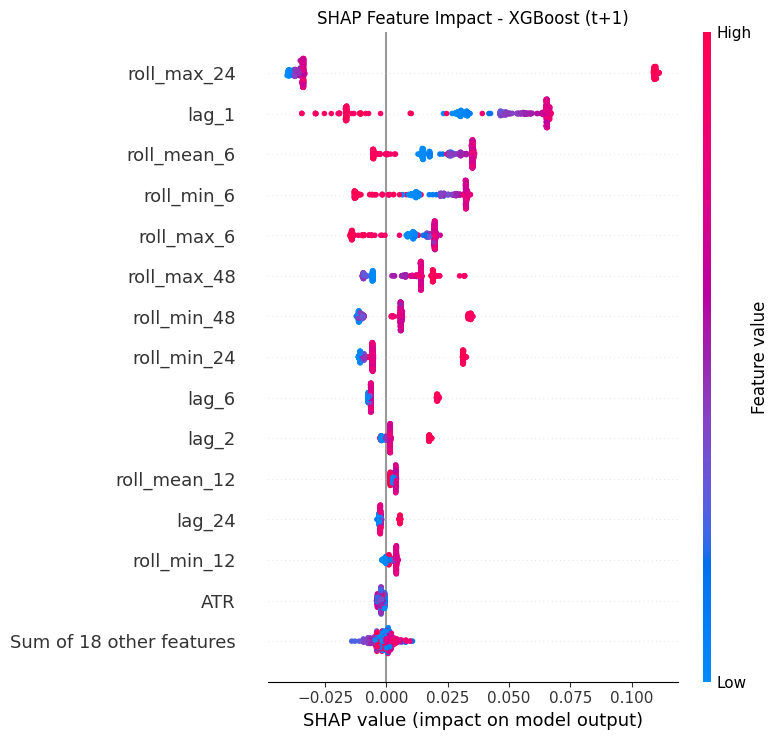

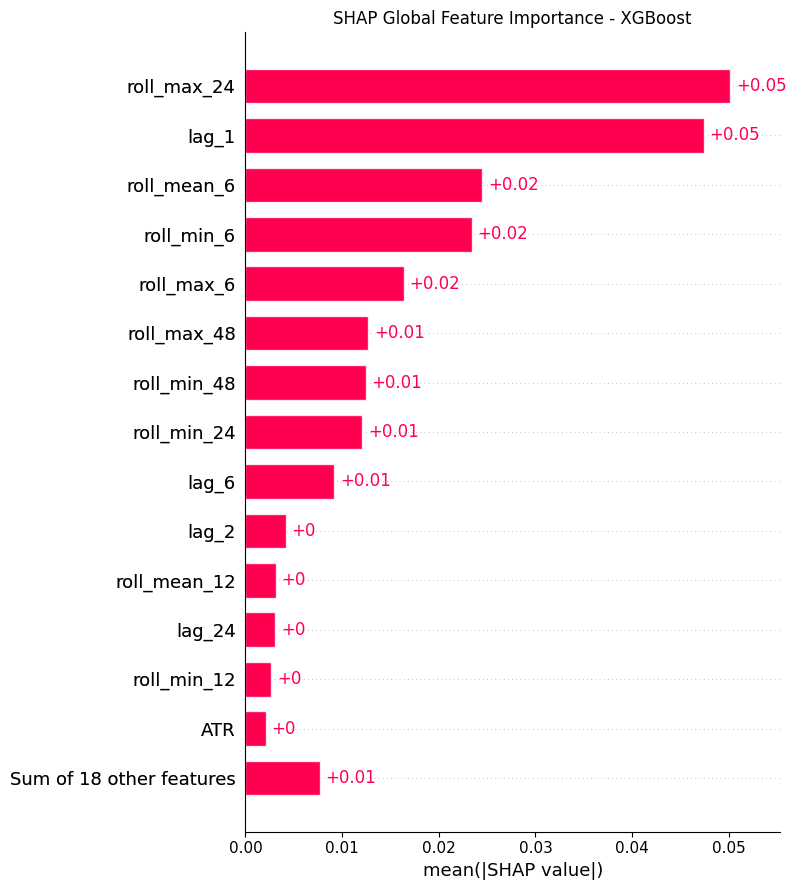

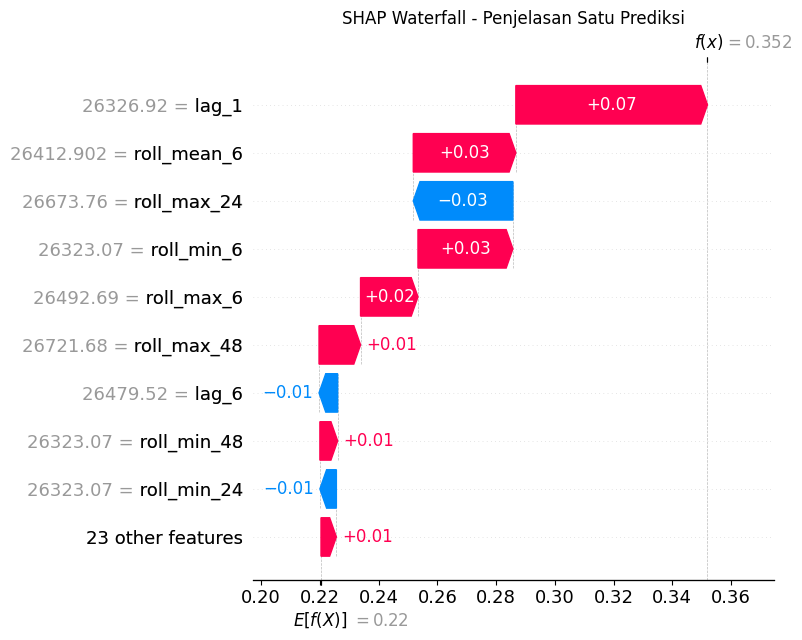

In [39]:
plt.figure()
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title('SHAP Feature Impact - XGBoost (t+1)')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure()
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title('SHAP Global Feature Importance - XGBoost')
plt.tight_layout()
plt.savefig('shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure()
shap.plots.waterfall(shap_values[0], show=False)
plt.title('SHAP Waterfall - Penjelasan Satu Prediksi')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.3 Pergeseran Pentingnya Fitur Antar Horizon

Fitur yang dominan untuk prediksi jangka pendek (t+1) belum tentu sama dengan jangka panjang (t+24). Perbandingan ini memberi insight bagaimana ketergantungan model berubah seiring jarak prediksi.

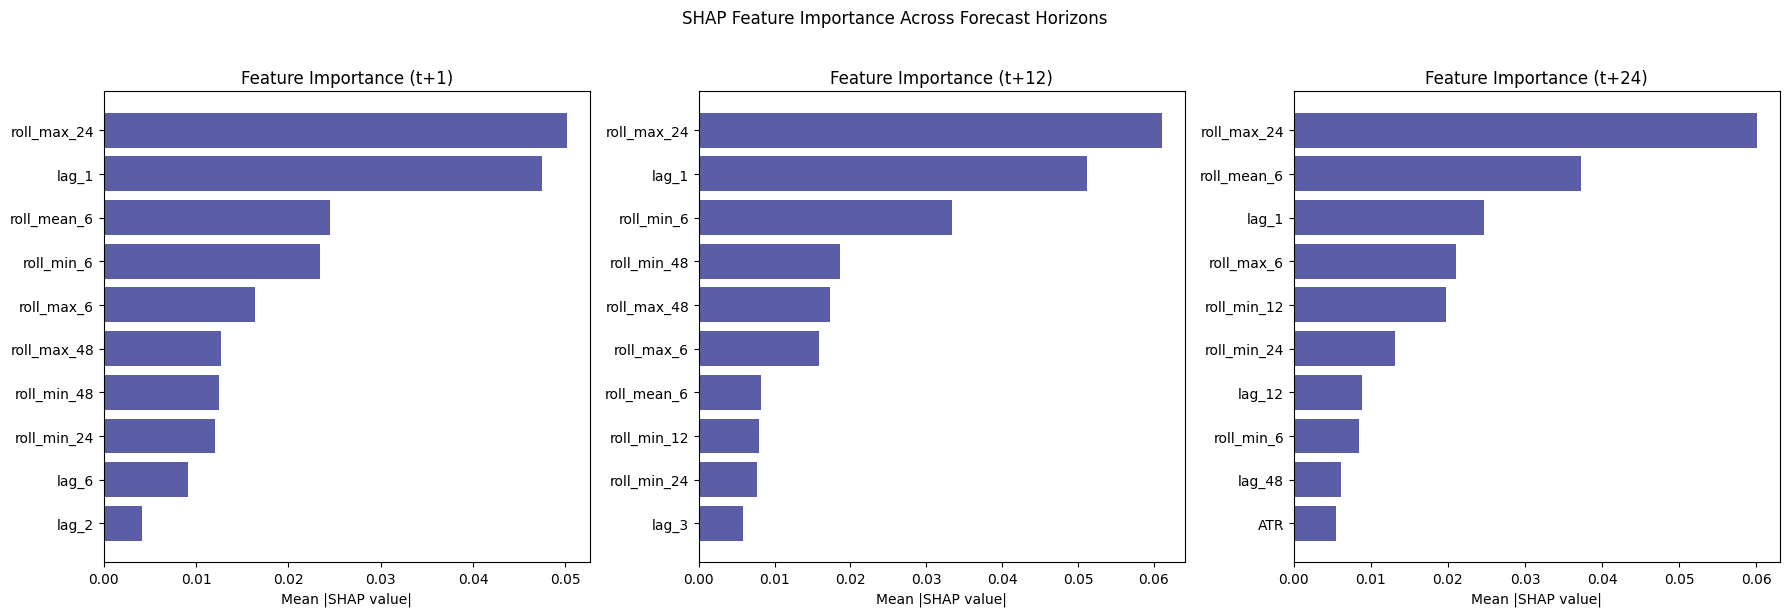

In [40]:
def importance_by_horizon(model, X_sample_df, n_top=10):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for ax, (h_idx, h_label) in zip(axes, [(0, 't+1'), (11, 't+12'), (23, 't+24')]):
        exp = shap.TreeExplainer(model.estimators_[h_idx])
        sv  = exp(X_sample_df)
        mean_abs = np.abs(sv.values).mean(axis=0)
        top = np.argsort(mean_abs)[-n_top:][::-1]
        ax.barh([X_sample_df.columns[i] for i in reversed(top)],
                mean_abs[list(reversed(top))], color='#5B5EA6')
        ax.set_title(f'Feature Importance ({h_label})')
        ax.set_xlabel('Mean |SHAP value|')
    plt.suptitle('SHAP Feature Importance Across Forecast Horizons', y=1.02)
    plt.tight_layout()
    plt.savefig('shap_horizon_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


importance_by_horizon(xgb_model, X_sample)

## 12. Experiment Tracking dengan MLflow

Seluruh konfigurasi, metrik, dan artefak dari ketiga pendekatan dicatat melalui MLflow untuk menjamin reproducibility dan memudahkan perbandingan antar eksperimen. Model TensorFlow dengan custom layer dicatat sebagai artefak `.keras` untuk menghindari masalah serialisasi.

### 12.1 Inisialisasi Experiment

In [41]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("bitcoin-forecasting-comparison")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

2026/06/12 10:00:29 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/12 10:00:29 INFO mlflow.store.db.utils: Updating database tables
2026/06/12 10:00:32 INFO mlflow.tracking.fluent: Experiment with name 'bitcoin-forecasting-comparison' does not exist. Creating a new experiment.


Tracking URI: sqlite:////content/mlflow.db


### 12.2 Pencatatan Runs

In [42]:
with mlflow.start_run(run_name="xgboost_multioutput"):
    mlflow.log_params({
        "model_type": "XGBoost_MultiOutput",
        "n_estimators": 500,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "n_features": len(feature_names),
        "horizon": HORIZON,
    })
    mlflow.log_metric("test_mae_scaled", xgb_test_mae)
    for art in ['shap_beeswarm.png', 'shap_importance_bar.png',
                'shap_waterfall.png', 'shap_horizon_comparison.png']:
        mlflow.log_artifact(art)
    mlflow.sklearn.log_model(xgb_model, "xgboost_model")

with mlflow.start_run(run_name="lstm_baseline_mha"):
    mlflow.log_params({
        "model_type": "LSTM_MultiHeadAttention",
        "lstm_units_1": 128, "lstm_units_2": 64, "mha_heads": 4,
        "dropout_rate": 0.2, "window_size": WINDOW_SIZE, "horizon": HORIZON,
        "batch_size": BATCH_SIZE, "learning_rate": 0.001, "loss_function": "MAE",
    })
    mlflow.log_metric("test_mae_scaled", baseline_test_loss)
    mlflow.log_artifact("model_baseline_LSTM.keras")

with mlflow.start_run(run_name="seq2seq_lstm_teacher_forcing"):
    mlflow.log_params({
        "model_type": "Seq2Seq_LSTM_TeacherForcing",
        "lstm_units": 128, "mha_heads": 4, "dropout_rate": 0.2,
        "window_size": WINDOW_SIZE, "horizon": HORIZON, "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE, "loss_function": "WeightedMAE_horizon",
        "teacher_forcing": True, "custom_training_loop": True,
    })
    mlflow.log_metric("test_mae_scaled", seq2seq_test_mae)
    mlflow.log_artifact("model_seq2seq_LSTM.keras")

print("Tiga runs berhasil dicatat.")

2026/06/12 10:00:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 10:00:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Tiga runs berhasil dicatat.


### 12.3 Ringkasan Runs

In [43]:
client = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name("bitcoin-forecasting-comparison")
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.test_mae_scaled ASC"],
)

print(f"{'Run Name':<35} {'Test MAE':<15} {'Model Type'}")
print("-" * 80)
for run in runs:
    name  = run.info.run_name
    mae   = run.data.metrics.get('test_mae_scaled', float('nan'))
    mtype = run.data.params.get('model_type', '-')
    print(f"{name:<35} {mae:<15.6f} {mtype}")

Run Name                            Test MAE        Model Type
--------------------------------------------------------------------------------
seq2seq_lstm_teacher_forcing        0.008022        Seq2Seq_LSTM_TeacherForcing
lstm_baseline_mha                   0.010899        LSTM_MultiHeadAttention
xgboost_multioutput                 0.013974        XGBoost_MultiOutput


## 13. Benchmark Foundation Model: Chronos (Zero-Shot)

Chronos-T5 dari Amazon dievaluasi secara zero-shot tanpa pelatihan ulang. Benchmark ini menempatkan performa model custom relatif terhadap foundation model berbasis Transformer yang telah dilatih pada beragam dataset time series, sehingga memberi konteks yang adil terhadap nilai dari pendekatan yang dibangun dari nol.

### 13.1 Memuat Pipeline Chronos

In [44]:
import torch
from chronos import ChronosPipeline

chronos_pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-tiny",
    device_map="cuda" if torch.cuda.is_available() else "cpu",
    torch_dtype=torch.bfloat16,
)

print(f"Chronos termuat pada: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/33.6M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

Chronos termuat pada: CUDA


### 13.2 Inferensi Zero-Shot

Chronos menerima konteks historis univariat (`Close`) sepanjang `WINDOW_SIZE` dan memprediksi 24 langkah ke depan. Median dari 20 sampel probabilistik dipakai sebagai titik prediksi, lalu diskalakan ke ruang yang sama dengan model lain untuk perhitungan MAE.

In [45]:
close_raw   = df['Close'].values
test_start  = int(len(df) * 0.85)
n_eval      = min(300, len(df) - test_start - HORIZON)

chronos_maes = []
for i in range(n_eval):
    idx = test_start + i
    ctx_start = max(0, idx - WINDOW_SIZE)
    context = close_raw[ctx_start:idx]
    actual  = close_raw[idx:idx + HORIZON]
    if len(actual) < HORIZON:
        break

    ctx_tensor = torch.tensor(context, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        forecast = chronos_pipeline.predict(ctx_tensor, HORIZON, num_samples=20)

    samples = forecast[0].cpu().float().numpy()
    median  = np.quantile(samples, 0.5, axis=0)
    median_scaled = scalers['Close'].transform(median.reshape(-1, 1)).flatten()
    actual_scaled = scalers['Close'].transform(actual.reshape(-1, 1)).flatten()
    chronos_maes.append(mean_absolute_error(actual_scaled, median_scaled))

chronos_test_mae = np.mean(chronos_maes)
print(f"Chronos T5-Tiny - Test MAE (scaled): {chronos_test_mae:.6f}")
print(f"Dievaluasi pada {len(chronos_maes)} sampel test.")

Chronos T5-Tiny - Test MAE (scaled): 0.002331
Dievaluasi pada 300 sampel test.


### 13.3 Perbandingan Akhir Seluruh Model

Model                                   Test MAE  Arsitektur
Chronos T5-Tiny (zero-shot)             0.002331  Foundation model, 20M params
Seq2Seq LSTM (Teacher Forcing)          0.008022  Encoder-decoder, custom loop
LSTM + Multi-Head Attention             0.010899  Trained from scratch
XGBoost (lag + rolling)                 0.013974  Tree ensemble, 500 est x 24


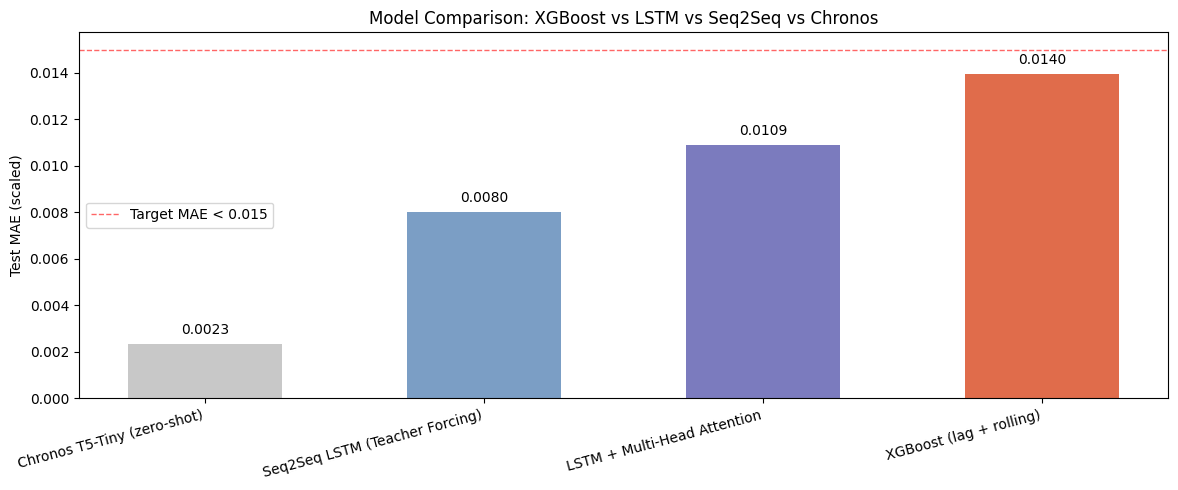

In [46]:
models_final = [
    ('Chronos T5-Tiny (zero-shot)',    chronos_test_mae,   'Foundation model, 20M params'),
    ('XGBoost (lag + rolling)',        xgb_test_mae,       'Tree ensemble, 500 est x 24'),
    ('LSTM + Multi-Head Attention',    baseline_test_loss, 'Trained from scratch'),
    ('Seq2Seq LSTM (Teacher Forcing)', seq2seq_test_mae,   'Encoder-decoder, custom loop'),
]
models_final.sort(key=lambda x: x[1])

print(f"{'Model':<35} {'Test MAE':>12}  {'Arsitektur'}")
print("=" * 85)
for name, mae, arch in models_final:
    print(f"{name:<35} {mae:>12.6f}  {arch}")

fig, ax = plt.subplots(figsize=(12, 5))
names  = [m[0] for m in models_final]
maes   = [m[1] for m in models_final]
colors = ['#C8C8C8', '#7B9EC5', '#7B7BBE', '#E06C4B']

bars = ax.bar(names, maes, color=colors[:len(names)], width=0.55)
ax.axhline(y=0.015, color='red', linestyle='--', linewidth=1, alpha=0.6,
           label='Target MAE < 0.015')
for bar, mae in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0003,
            f'{mae:.4f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Test MAE (scaled)')
ax.set_title('Model Comparison: XGBoost vs LSTM vs Seq2Seq vs Chronos')
ax.legend()
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('model_comparison_final.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Ringkasan Artefak

In [47]:
import os

artifacts = [
    'model_baseline_LSTM.keras',
    'model_seq2seq_LSTM.keras',
    'best_model_seq2seq_LSTM.keras',
    'shap_beeswarm.png',
    'shap_importance_bar.png',
    'shap_waterfall.png',
    'shap_horizon_comparison.png',
    'model_comparison_final.png',
]

for a in artifacts:
    print(f"  {'OK ' if os.path.exists(a) else 'MISSING'}  {a}")

  OK   model_baseline_LSTM.keras
  OK   model_seq2seq_LSTM.keras
  OK   best_model_seq2seq_LSTM.keras
  OK   shap_beeswarm.png
  OK   shap_importance_bar.png
  OK   shap_waterfall.png
  OK   shap_horizon_comparison.png
  OK   model_comparison_final.png
